In [4]:
#set the environment variable for Groq API key
import os

if "GROQ_API_KEY" not in os.environ:
    print("Warning: GROQ_API_KEY environment variable not set")


In [5]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)


Define a Graph

-Define a llm schema for the topic categorize

In [ ]:
from pydantic import BaseModel,Field
from typing import Literal
class llm_schema(BaseModel):
    topic: Literal["insta","facebook","twitter"] = Field(description="About the post topic")


In [ ]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_schema.invoke("I want to generate the post for instagram about ai") #if we invoke the linkedin in our query then error occurs due to the literal list we used above

llm_schema(topic='insta')

Define state graph

In [ ]:
from typing import TypedDict
class Graph_Schema(TypedDict):
    topic: str
    category: str
    post: str


Create a NodeGraph

In [ ]:
def create_inta_post(Graph_Schema)-> Graph_Schema:
    topic = state["topic"]
    post = llm.invoke("create a post about the topic:{topic}")
    state["post"] = post
    return state

def create_facebook_post(Graph_Schema) -> Graph_Schema:
    topic = state["topic"]
    post = llm.invoke("create a post about the topic:{topic}")
    state["post"] = post
    return state

def create_twitter_post(Graph_Schema) -> Graph_Schema:
    topic = state["topic"]
    post = llm.invoke("create a post about the topic:{topic}")
    state["post"] = post
    return state

def post_decider():
    category = state["category"]

    if category == "insta":
        return create_inta_post

    elif category == "facebook":
        return create_facebook_post
    
    elif category == "twitter":
        return create_twitter_post

    else:
        return END
    

CREATE THE STATE GRAPH

In [ ]:
from langgraph.graph import StateGraph,START,END
graph = StateGraph(Graph_Schema)

#add node
graph.add_node("create_insta_post",create_inta_post)
graph.add_node("create_facebook_post",create_facebook_post)
graph.add_node("create_twitter_post",create_twitter_post)
graph.add_node("post_decider",post_decider)

#add edges
graph.add_edge(START,"post_decider")
graph.add_edge("post_decider",condition)



COMPILE THE GRAPH

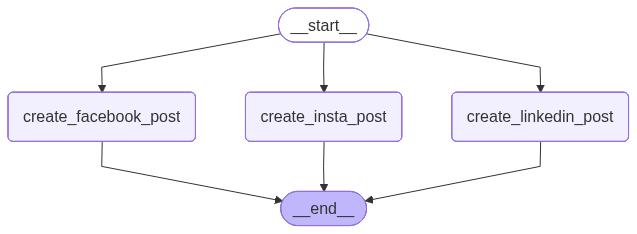

In [26]:
from IPython.display import Image,display

parallel_graph = graph.compile()
Image(parallel_graph.get_graph().draw_mermaid_png())

RUN THE GRAPH

In [27]:
parallel_graph.invoke({"topic": "AI News",
                    "insta": "",
                    "facebook": "",
                    "linkedin": ""
})

{'topic': 'AI News',
 'insta': 'Here\'s a possible Instagram post on the topic of AI News with a more engaging tone:\n\n**POST TITLE:** "The Future is Here: Mind-Blowing AI News You Need to Know! "\n\n**IMAGE:** A futuristic illustration of a cityscape with AI-powered robots and drones flying around, or a photo of a person interacting with a smart AI assistant.\n\n**CAPTION:**\n\n"Get ready to level up your life with the latest AI news!\n\nFrom AI-powered robots that can perform surgery to virtual assistants that can read your mind, we\'re living in a world where the boundaries between humans and machines are blurring fast!\n\nHere are the top AI news stories you need to know:\n\n 1. **AI-Powered Surgery:** Robots are now assisting surgeons in the operating room, making precision cuts and reducing recovery time.\n 2. **Mind-Reading Virtual Assistants:** AI-powered assistants can now read your brain signals and respond accordingly, changing the way we interact with technology forever!\n